In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from compute_transport import *
import torch
import torch.nn.functional as F
from evaluation_metrics import *
from refcm import RefCM
from refcm.embeddings import HVGEmbedder
import anndata
import time

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(20, 10), facecolor='white')

In [3]:
df_fov = pd.read_pickle('mk_bc_fov.pkl')
df_fov = df_fov[df_fov.index != 'OFFx']
df_fov

GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
DB3b,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FMB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IMB,0.0,0.0,0.782327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB5*,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB5*,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB4,0.0,0.0,0.633187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IMB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Generate unique mapping for index values
unique_index_values = df_fov.index.unique()
index_mapping = {key: value for value, key in enumerate(unique_index_values)}

# Display the mapping
print("Mapping of annotated values to numbers:")
print(index_mapping)

# Optionally, create a new column with numeric representation
df_fov.index = df_fov.index.map(index_mapping)
df_fov

Mapping of annotated values to numbers:
{'DB3b': 0, 'FMB': 1, 'IMB': 2, 'DB5*': 3, 'DB4': 4, 'DB2': 5, 'DB1': 6, 'BB/GB*': 7, 'RB': 8, 'DB6': 9, 'DB3a': 10}


GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.782327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.633187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# fov_index_mapping = {'DB3b': 0, 'FMB': 1, 'IMB': 2, 'DB5*': 3, 'DB4': 4, 'DB2': 5, 'DB1': 6, 'BB/GB*': 7, 'RB': 8, 'DB6': 9, 'OFFx': 10, 'DB3a': 11}
fov_index_mapping = {'DB3b': 0, 'FMB': 1, 'IMB': 2, 'DB5*': 3, 'DB4': 4, 'DB2': 5, 'DB1': 6, 'BB/GB*': 7, 'RB': 8, 'DB6': 9, 'DB3a': 10}
fov_bc_mapping = {value: key for key, value in fov_index_mapping.items()}
fov_bc_mapping

{0: 'DB3b',
 1: 'FMB',
 2: 'IMB',
 3: 'DB5*',
 4: 'DB4',
 5: 'DB2',
 6: 'DB1',
 7: 'BB/GB*',
 8: 'RB',
 9: 'DB6',
 10: 'DB3a'}

In [6]:
# transform cell type index into a number between 100 and 200
df_fov.index = df_fov.index+101
df_fov

GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
101,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
103,0.0,0.0,0.782327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,0.0,0.0,0.633187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
103,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df_per = pd.read_pickle('mk_bc_per.pkl')
df_per

GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
RB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
FMB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.594012,0.0
FMB,0.0,0.0,1.039235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.039235,0.0
DB2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
IMB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.125773,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.591334,0.0,0.0,0.000000,0.0
RB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
RB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.154855,0.0
RB,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [8]:
# Generate unique mapping for index values
unique_index_values = df_per.index.unique()
index_mapping = {key: value for value, key in enumerate(unique_index_values)}

# Display the mapping
print("Mapping of annotated values to numbers:")
print(index_mapping)

# Optionally, create a new column with numeric representation
df_per.index = df_per.index.map(index_mapping)
df_per

Mapping of annotated values to numbers:
{'RB': 0, 'FMB': 1, 'DB2': 2, 'IMB': 3, 'DB5*': 4, 'DB3b': 5, 'DB3a': 6, 'BB/GB*': 7, 'DB1': 8, 'DB4': 9, 'DB6': 10}


GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.594012,0.0
1,0.0,0.0,1.039235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.039235,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.125773,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.591334,0.0,0.0,0.000000,0.0
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.154855,0.0
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [9]:
per_index_mapping = {'RB': 0, 'FMB': 1, 'DB2': 2, 'IMB': 3, 'DB5*': 4, 'DB3b': 5, 'DB3a': 6, 'BB/GB*': 7, 'DB1': 8, 'DB4': 9, 'DB6': 10}
per_bc_mapping = {value: key for key, value in per_index_mapping.items()}
per_bc_mapping

{0: 'RB',
 1: 'FMB',
 2: 'DB2',
 3: 'IMB',
 4: 'DB5*',
 5: 'DB3b',
 6: 'DB3a',
 7: 'BB/GB*',
 8: 'DB1',
 9: 'DB4',
 10: 'DB6'}

In [10]:
# transform cell type index into a number above 200
df_per.index = df_per.index+201
df_per

GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
202,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.594012,0.0
202,0.0,0.0,1.039235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.039235,0.0
203,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
204,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.125773,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.591334,0.0,0.0,0.000000,0.0
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.154855,0.0
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [11]:
df = pd.concat([df_fov, df_per], axis=0)
df

GENE,ZNF692,ZNF672_p,SH3BP5L,LOC102131547,LOC107126559,ZNF496,LOC102144076,LOC102145193,ZNF124,ZNF669,...,TMLHE,MSTRG.23232,MSTRG.23233,MSTRG.23234,MSTRG.23235,MSTRG.23237,MSTRG.23238,MSTRG.23242,MSTRG.23240,MSTRG.23243
101,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
102,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
103,0.0,0.0,0.782327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
104,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
105,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.591334,0.0,0.0,0.000000,0.0
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.154855,0.0
201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [12]:
# Calculate counts, means, and variances per cell type
type_counts = df.groupby(df.index).count()  # Count of cells per type
type_means = df.groupby(df.index).mean()    # Mean expression per type
type_vars = df.groupby(df.index).var()      # Variance per type

# Calculate SEM for each type
type_sems = type_vars.div(type_counts - 1).pow(0.5)  # SEM = sqrt(var/(n-1))

# Calculate overall mean expression for each gene
overall_means = df.mean()

# Calculate signal
signal = ((type_means - overall_means)**2).sum()

# Calculate noise
noise = (type_sems**2).sum()

# Calculate SNR, avoiding division by zero
snr = signal / np.maximum(noise, 1e-20)

# Sort genes by SNR in descending order
sorted_genes = snr.sort_values(ascending=False)

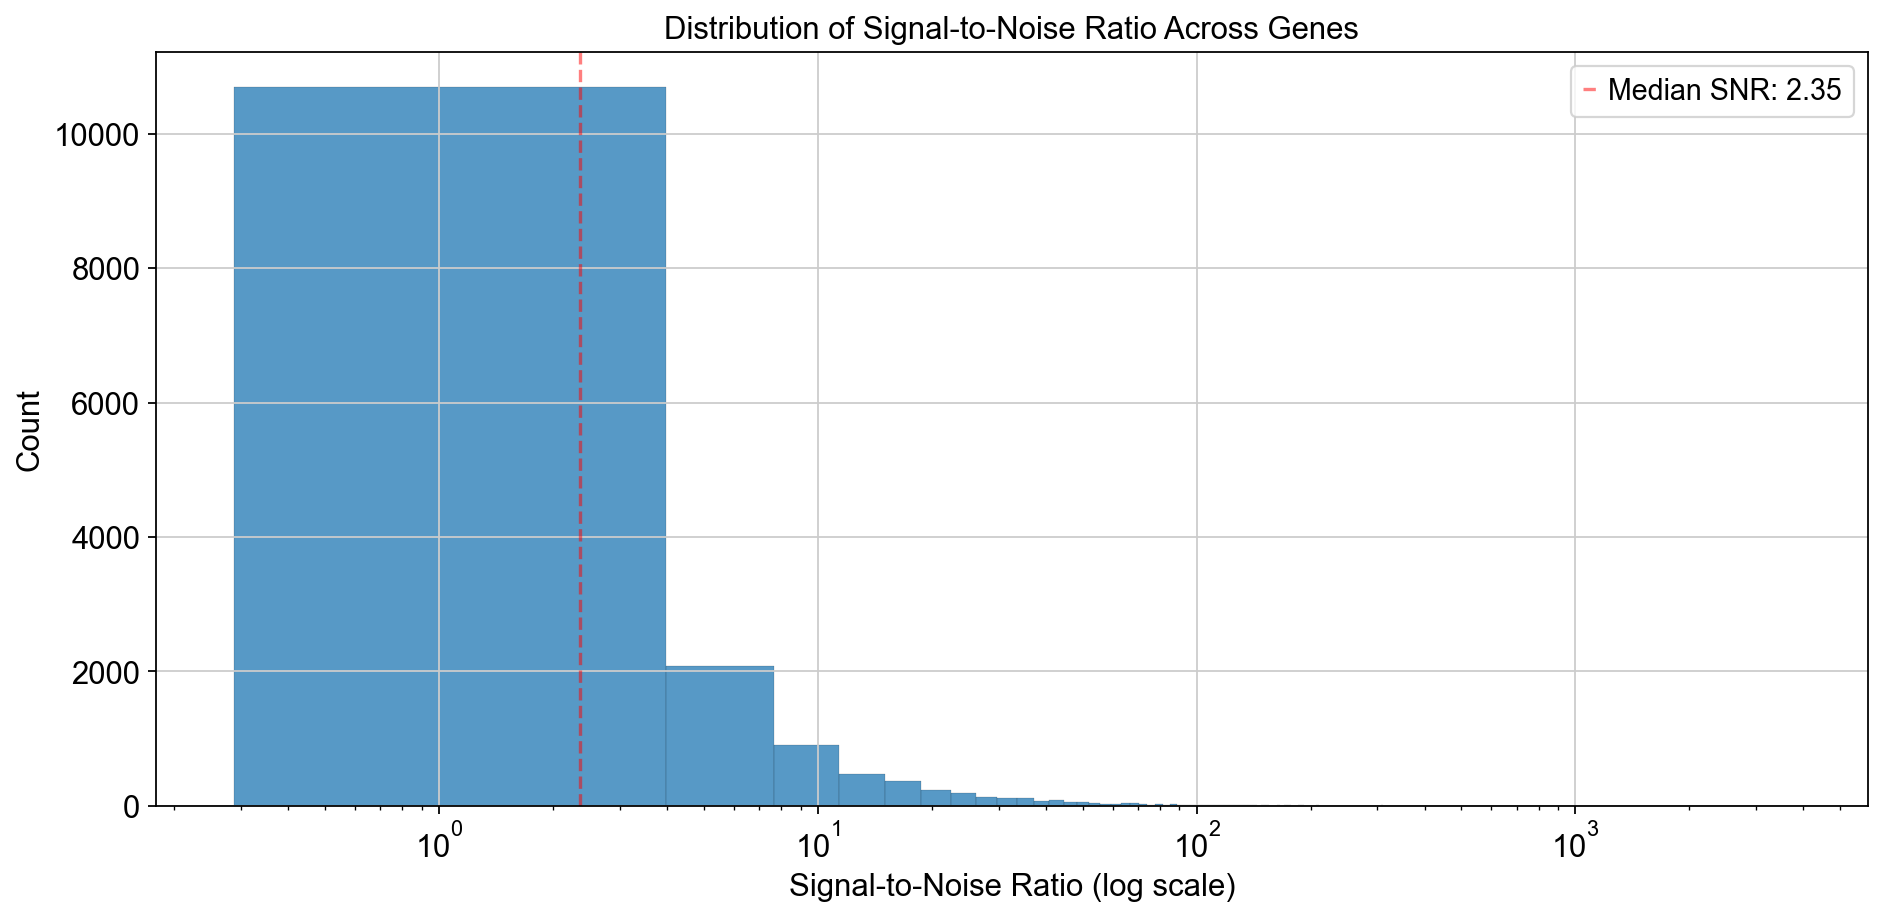


SNR Summary Statistics:
count    16161.000000
mean        10.884119
std         52.221137
min          0.286768
25%          1.365612
50%          2.353347
75%          6.032673
max       3688.980919
dtype: float64


In [13]:
# Create figure
plt.figure(figsize=(12, 6))

# Plot histogram with KDE
sns.histplot(data=snr, bins=1000)

# Add log scale for x-axis since SNR values often span several orders of magnitude
plt.xscale('log')

# Customize the plot
plt.title('Distribution of Signal-to-Noise Ratio Across Genes')
plt.xlabel('Signal-to-Noise Ratio (log scale)')
plt.ylabel('Count')

# Add grid for better readability
# plt.grid(True, which="both", ls="-", alpha=0.2)

# Optional: Add vertical line at median
plt.axvline(snr.median(), color='r', linestyle='--', alpha=0.5, label=f'Median SNR: {snr.median():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print some summary statistics
print("\nSNR Summary Statistics:")
print(snr.describe())

In [14]:
# Select genes with high SNR
high_snr_genes = snr[snr > 100]

# Print number of selected genes
print(f"Number of genes with great SNR: {len(high_snr_genes)}")

# Create filtered dataframe with only high SNR genes
df_filtered = df[high_snr_genes.index]

# Optional: Display first few rows and shape of filtered dataframe
print(f"\nShape of filtered dataframe: {df_filtered.shape}")
print("\nFirst few rows of filtered dataframe:")
print(df_filtered.head())

Number of genes with great SNR: 271

Shape of filtered dataframe: (30155, 271)

First few rows of filtered dataframe:
GENE   PROX1_p     TGFB2  KCNA3  MSTRG.1569     STMN1  RAP1GAP     RGS16  \
101   0.000000  0.000000    0.0    0.641217  0.000000      0.0  0.000000   
102   0.000000  0.000000    0.0    0.000000  0.000000      0.0  0.000000   
103   0.000000  0.000000    0.0    0.782327  1.517249      0.0  0.782327   
104   1.036175  0.000000    0.0    0.000000  1.036175      0.0  0.000000   
105   0.980239  0.605707    0.0    0.000000  0.605707      0.0  0.000000   

GENE  LOC102135846      NEK2    LPGAT1  ...  MSTRG.22359  MSTRG.22360  \
101            0.0  0.000000  0.000000  ...     0.641217     3.033673   
102            0.0  1.392702  0.000000  ...     0.697424     1.392702   
103            0.0  0.000000  0.000000  ...     0.782327     2.457792   
104            0.0  0.000000  0.646688  ...     0.000000     2.954085   
105            0.0  0.000000  0.000000  ...     0.980239    

In [15]:
fov_sub_df = df_filtered[df_filtered.index < 200]
per_sub_df = df_filtered[df_filtered.index >= 200]

# Print information about the split
print(f"Fovea dataframe shape: {fov_sub_df.shape}")
print(f"Peripheral dataframe shape: {per_sub_df.shape}")

# Optional: Display first few rows of each
print("\nFirst few rows of fovea dataframe:")
print(fov_sub_df.head())
print("\nFirst few rows of peripheral dataframe:")
print(per_sub_df.head())

Fovea dataframe shape: (20870, 271)
Peripheral dataframe shape: (9285, 271)

First few rows of fovea dataframe:
GENE   PROX1_p     TGFB2  KCNA3  MSTRG.1569     STMN1  RAP1GAP     RGS16  \
101   0.000000  0.000000    0.0    0.641217  0.000000      0.0  0.000000   
102   0.000000  0.000000    0.0    0.000000  0.000000      0.0  0.000000   
103   0.000000  0.000000    0.0    0.782327  1.517249      0.0  0.782327   
104   1.036175  0.000000    0.0    0.000000  1.036175      0.0  0.000000   
105   0.980239  0.605707    0.0    0.000000  0.605707      0.0  0.000000   

GENE  LOC102135846      NEK2    LPGAT1  ...  MSTRG.22359  MSTRG.22360  \
101            0.0  0.000000  0.000000  ...     0.641217     3.033673   
102            0.0  1.392702  0.000000  ...     0.697424     1.392702   
103            0.0  0.000000  0.000000  ...     0.782327     2.457792   
104            0.0  0.000000  0.646688  ...     0.000000     2.954085   
105            0.0  0.000000  0.000000  ...     0.980239     3.043

In [16]:
# transform the index back to cell type names
per_sub_df.index = per_sub_df.index - 201
per_sub_df.index = per_sub_df.index.map(per_bc_mapping)
per_sub_df

GENE,PROX1_p,TGFB2,KCNA3,MSTRG.1569,STMN1,RAP1GAP,RGS16,LOC102135846,NEK2,LPGAT1,...,MSTRG.22359,MSTRG.22360,MSTRG.22363,MSTRG.22367,MSTRG.22513,TMSB4X,LOC102125362,PCDH11X,LOC107128460,ANOS1
RB,1.143564,0.0,0.0,0.727049,0.727049,1.300849,0.000000,0.0,0.0,1.663142,...,2.458704,1.143564,3.154797,1.436725,0.000000,1.663142,0.956837,0.0,0.000000,1.143564
FMB,0.000000,0.0,0.0,0.000000,0.594012,0.000000,0.000000,0.0,0.0,0.000000,...,1.233644,0.000000,2.116395,0.000000,0.000000,0.594012,0.000000,0.0,0.000000,0.000000
FMB,0.000000,0.0,0.0,0.000000,1.537750,0.000000,0.000000,0.0,0.0,1.537750,...,1.537750,1.039235,3.049159,1.039235,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
DB2,0.000000,0.0,0.0,0.885618,1.662684,0.000000,0.000000,0.0,0.0,0.000000,...,2.517362,0.885618,3.107597,0.537803,0.000000,2.769901,0.000000,0.0,0.000000,0.000000
IMB,1.125773,0.0,0.0,1.125773,0.000000,0.000000,1.125773,0.0,0.0,1.125773,...,2.233278,1.125773,2.434753,1.125773,0.000000,1.125773,0.000000,0.0,1.125773,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RB,1.229404,0.0,0.0,0.591334,0.591334,0.000000,1.441158,0.0,0.0,0.000000,...,2.440881,0.591334,1.229404,1.229404,0.000000,0.591334,1.229404,0.0,0.000000,0.591334
RB,0.000000,0.0,0.0,0.742880,0.000000,0.000000,1.164388,0.0,0.0,0.000000,...,2.654915,0.000000,1.687866,1.164388,0.000000,1.873325,1.459996,0.0,0.000000,0.000000
RB,1.154855,0.0,0.0,0.895697,0.544949,0.000000,1.154855,0.0,0.0,0.895697,...,2.271533,0.000000,1.916359,0.895697,1.154855,0.895697,1.154855,0.0,0.895697,0.000000
RB,0.555288,0.0,0.0,0.910226,0.910226,0.000000,1.171654,0.0,0.0,0.555288,...,2.293474,0.555288,1.378708,0.910226,0.910226,1.171654,1.171654,0.0,0.555288,0.555288


In [17]:
# transform the index back to cell type names
fov_sub_df.index = fov_sub_df.index - 101
fov_sub_df.index = fov_sub_df.index.map(fov_bc_mapping)
fov_sub_df

GENE,PROX1_p,TGFB2,KCNA3,MSTRG.1569,STMN1,RAP1GAP,RGS16,LOC102135846,NEK2,LPGAT1,...,MSTRG.22359,MSTRG.22360,MSTRG.22363,MSTRG.22367,MSTRG.22513,TMSB4X,LOC102125362,PCDH11X,LOC107128460,ANOS1
DB3b,0.000000,0.000000,0.0,0.641217,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.641217,3.033673,0.000000,0.000000,0.0,0.641217,0.000000,0.0,0.000000,0.000000
FMB,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.392702,0.000000,...,0.697424,1.392702,1.104310,0.000000,0.0,0.697424,0.697424,0.0,0.000000,0.000000
IMB,0.000000,0.000000,0.0,0.782327,1.517249,0.0,0.782327,0.0,0.000000,0.000000,...,0.782327,2.457792,0.782327,1.748542,0.0,1.748542,0.000000,0.0,0.000000,0.000000
DB5*,1.036175,0.000000,0.0,0.000000,1.036175,0.0,0.000000,0.0,0.000000,0.646688,...,0.000000,2.954085,0.646688,0.000000,0.0,1.864893,0.646688,0.0,0.000000,0.646688
DB4,0.980239,0.605707,0.0,0.000000,0.605707,0.0,0.000000,0.0,0.000000,0.000000,...,0.980239,3.043624,0.000000,0.605707,0.0,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB5*,0.000000,0.000000,0.0,1.045827,1.045827,0.0,0.000000,0.0,0.000000,1.045827,...,1.877517,0.000000,0.000000,0.000000,0.0,1.877517,0.000000,0.0,0.000000,1.045827
DB4,0.000000,0.000000,0.0,0.000000,1.489646,0.0,0.000000,0.0,0.000000,0.000000,...,0.999809,0.000000,0.000000,0.000000,0.0,0.000000,0.999809,0.0,0.000000,0.000000
DB4,0.000000,0.000000,0.0,0.633187,1.840808,0.0,0.000000,0.0,0.000000,0.000000,...,1.511697,0.000000,0.000000,0.000000,0.0,1.294950,0.000000,0.0,0.000000,0.000000
IMB,0.000000,0.000000,0.0,1.309678,0.000000,0.0,0.855475,0.0,0.000000,0.000000,...,2.049298,0.000000,1.309678,0.855475,0.0,1.857853,0.000000,0.0,0.000000,0.000000


In [18]:
# Calculate mean expression per cell type for both
fov_type_means = fov_sub_df.groupby(fov_sub_df.index).mean()
per_type_means = per_sub_df.groupby(per_sub_df.index).mean()

# Convert to torch tensors
fov_tensor = torch.tensor(fov_type_means.values, dtype=torch.float32)
per_tensor = torch.tensor(per_type_means.values, dtype=torch.float32)

# Normalize the vectors
fov_norm = F.normalize(fov_tensor, dim=1)
per_norm = F.normalize(per_tensor, dim=1)

# Compute cosine similarity (1 - cosine distance)
distance_matrix = pd.DataFrame(
    1- torch.mm(fov_norm, per_norm.t()).numpy(),
    index=fov_type_means.index,
    columns=per_type_means.index
)

In [19]:
# for plotting in the same order as that in Peng, et al. (2019)
desired_order2 = [
    "FMB",    # FMB (top)
    "DB1",    # DB1
    "DB2",    # DB2
    "DB3a",   # DB3a
    "DB3b",   # DB3b
    "IMB",    # IMB
    "DB4",    # DB4
    "BB/GB*", # BB/GB*
    "DB6",    # DB6
    "DB5*",   # DB5*
    "RB"      # RB (bottom)
]

desired_order1 = [
    "FMB",    # FMB (top)
    "DB1",    # DB1
    # "OFFx",   # OFFx
    "DB2",    # DB2
    "DB3a",   # DB3a
    "DB3b",   # DB3b
    "IMB",    # IMB
    "DB4",    # DB4
    "BB/GB*", # BB/GB*
    "DB6",    # DB6
    "DB5*",   # DB5*
    "RB"      # RB (bottom)
]

In [20]:
# %%
def prepare_anndata_for_refcm(df, cluster_key='cell_type'):
    """
    Convert DataFrame to AnnData format expected by RefCM.
    """
    # Create AnnData object with raw counts
    adata = anndata.AnnData(X=df.values.astype(np.float32))
    adata.obs_names = [f'cell_{i}' for i in range(df.shape[0])]
    adata.var_names = df.columns
    
    # Add cluster information
    adata.obs[cluster_key] = df.index.values
    
    # RefCM expects raw counts, so ensure non-negative
    adata.X = np.maximum(adata.X, 0)
    
    return adata

# %%
def run_refcm_strict(fov_df, per_df, desired_order1, desired_order2):
    """
    Run RefCM with strict 1-to-1 mapping on the bipolar cell data.
    """
    # Prepare data in RefCM's expected format
    print("Preparing data for RefCM...")
    
    # Create AnnData objects
    query_adata = prepare_anndata_for_refcm(fov_df.loc[desired_order1], 'fov_type')
    ref_adata = prepare_anndata_for_refcm(per_df.loc[desired_order2], 'per_type')
    
    print(f"Query shape: {query_adata.shape}")
    print(f"Reference shape: {ref_adata.shape}")
    
    print("\nRunning RefCM with strict 1-to-1 mapping...")
    
    # Initialize RefCM with strict 1-to-1 parameters
    refcm = RefCM(
        max_merges=1,
        max_splits=1,
        discovery_threshold=0.0,  # Threshold for novel cell type detection
        verbose_solver=False,
        embedder=HVGEmbedder(n_top_genes=271), # The same number of genes as SNR based
        cache_save=False,  # Don't save cache for benchmark
        cache_load=False   # Don't load cache for fair timing
    )
    
    # Set reference
    refcm.setref(ref_adata, ref_id='peripheral', ref_key='per_type')
    
    # Time the annotation
    start_time = time.time()
    matching = refcm.annotate(query_adata, q_id='foveal', q_key='fov_type')
    runtime = time.time() - start_time
    
    # Extract the mapping matrix from RefCM's results
    mapping_matrix = query_adata.uns['refcm_mapping']
    
    # Convert to transport matrix (normalize)
    transport_matrix = mapping_matrix / (mapping_matrix.sum() + 1e-10)
    
    # Create DataFrame with proper indices
    transport_df = pd.DataFrame(
        transport_matrix,
        index=desired_order1,
        columns=desired_order2
    )
    
    # Calculate metrics
    print(f"\nRefCM Results:")
    print(f"Runtime: {runtime:.4f} seconds")
    
    # Ensure the matrix is normalized
    if not np.isclose(transport_df.values.sum(), 1.0):
        transport_df = transport_df / transport_df.values.sum()
    
    # Calculate metrics
    sparseness = sparseness_score(transport_df.values)
    entropy_value = entropy(transport_df.values)
    adi = adjusted_rand_index_from_confusion_matrix(transport_df.values)
    
    print(f"\nCorrespondence Matrix Evaluation Results:")
    print("----------------------------------------")
    print(f"Sparseness Score: {sparseness:.4f}")
    print(f"Entropy: {entropy_value:.4f}")
    print(f"ADI: {adi:.4f}")
    
    # Additional information
    print(f"\nMatrix Information:")
    print(f"Shape: {transport_df.shape}")
    print(f"Number of cells: {transport_df.size}")
    print(f"Number of cells with value > 0.001: {np.sum(transport_df.values > 0.001)}")
    print(f"Maximum value: {transport_df.values.max():.4f}")
    print(f"Sum of diagonal elements: {np.sum(np.diag(transport_df.values)):.4f}")
    
    return transport_df, runtime

# %%
def plot_refcm_transport(transport_df, runtime):
    """
    Plot the RefCM transport matrix.
    """
    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(transport_df, cmap='bwr', square=True,
                     annot=True, fmt='.3f')
    
    # Set y-axis labels to horizontal
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.title(f'RefCM Transport Matrix', fontsize=14)
    plt.xlabel('Peripheral BC Types (Query)', fontsize=12)
    plt.ylabel('Foveal BC Types (Reference)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('./Plots/refcm_transport_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

In [21]:
# Run RefCM with strict 1-to-1 mapping
transport_df, runtime = run_refcm_strict(fov_sub_df, per_sub_df, desired_order1, desired_order2)

Preparing data for RefCM...
Query shape: (20870, 271)
Reference shape: (9285, 271)

Running RefCM with strict 1-to-1 mapping...
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 00:34


RefCM Results:
Runtime: 34.4387 seconds

Correspondence Matrix Evaluation Results:
----------------------------------------
Sparseness Score: 0.9091
Entropy: 2.3979
ADI: 1.0000

Matrix Information:
Shape: (11, 11)
Number of cells: 121
Number of cells with value > 0.001: 11
Maximum value: 0.0909
Sum of diagonal elements: 1.0000


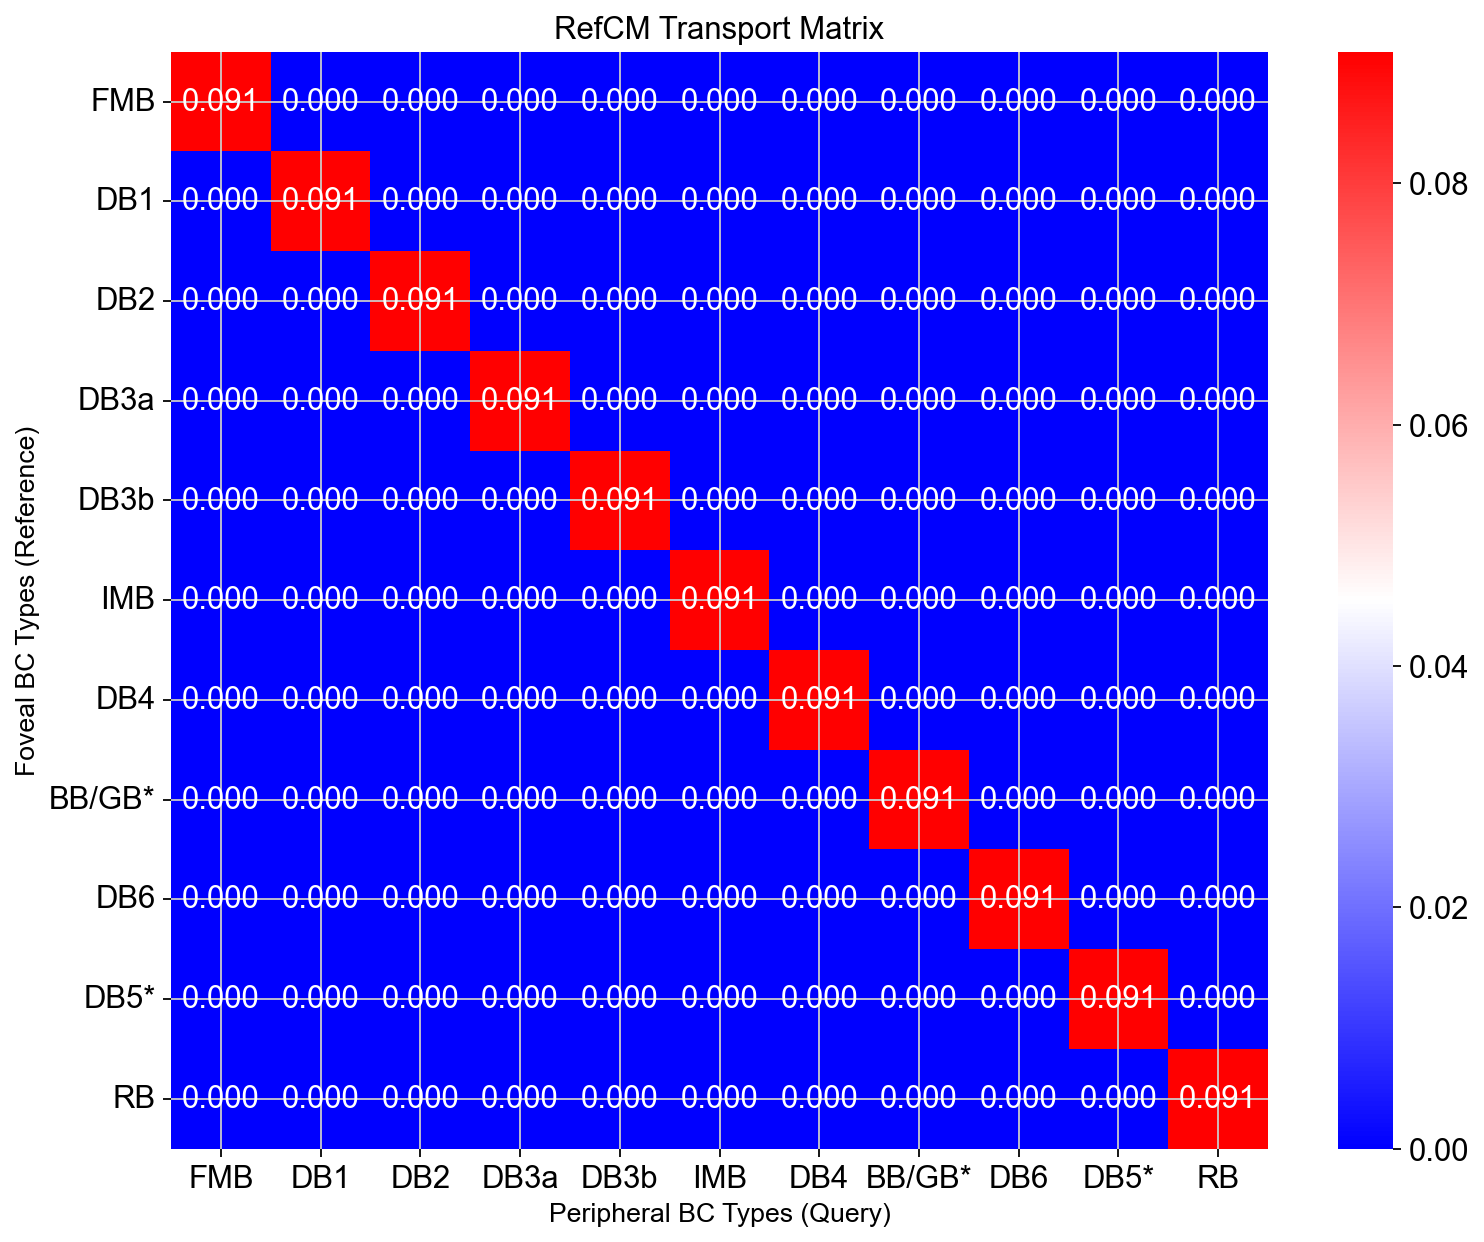

In [22]:
# Plot the transport matrix
plot_refcm_transport(transport_df, runtime)